# Forecast-Driven Hazard Alarm Demo

This notebook is only a thin demo wrapper.

- All simulation, terrain, weather, hotspot ranking, and alert logic lives in `windsimulator/`.
- Edit only the location, incident time, and severity below.
- Set `incident_time` to an ISO UTC string like `"2026-03-29T18:00:00Z"`, or leave it as `"auto"` to use the next forecast hour.
- The library will fetch public weather and elevation data, simulate the plume, render a timelapse overlay, and list top neighborhoods, cities, and postal / ZIP codes.
- This remains a simplified prototype, not a validated evacuation system.


All required packages are already installed.


Starting forecast-driven hazard demo.
Inputs: location=(37.7749, -122.4194), incident_time=auto, severity=severe, incident_type=leakage.
1/5 Fetching hourly weather forecast near (37.7749, -122.4194).


2/5 Sampling public elevation data and building the terrain grid at resolution 10x10.


3/5 Simulating 3 hourly plume snapshots using the forecast wind steps.
4/5 Reverse-geocoding the strongest simulated hotspots into neighborhood, city, and ZIP labels.


5/5 Packaging the overlay, timelapse, ranked impact tables, and draft notice payloads.
Run summary: 3 forecast steps from 2026-03-29 09:00 UTC to 2026-03-29 11:00 UTC.
Under the hood: public weather forecast -> terrain elevation grid -> plume snapshots -> reverse-geocoded hotspots -> ranked alert tables.
Top hotspot labels found: 4 (highest simulated band: HIGH).


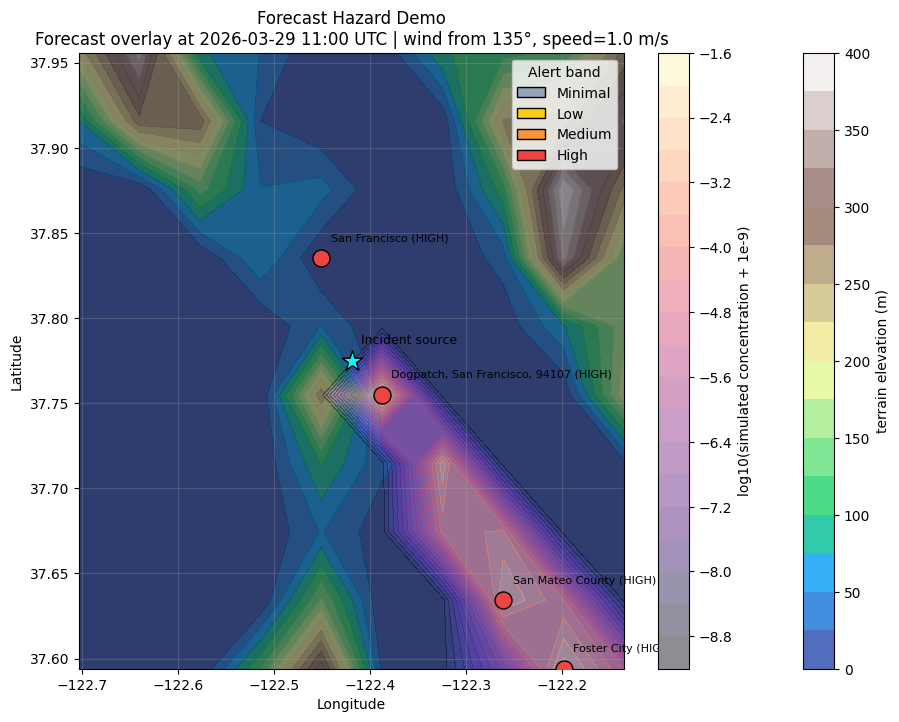

Top impacted neighborhoods


,Neighborhood,City,PostalCode,PeakBand,PeakConcentration,FirstImpactedTime,RecommendedAction
0,Dogpatch,San Francisco,94107,HIGH,0.010195,2026-03-29 11:00:00+00:00,Immediate evacuation order


Top impacted cities


,City,State,Country,PeakBand,PeakConcentration,FirstImpactedTime,HotspotCount,RecommendedAction
0,San Francisco,California,United States,HIGH,0.010195,2026-03-29 09:00:00+00:00,2,Immediate evacuation order
1,Foster City,California,United States,HIGH,0.002566,2026-03-29 11:00:00+00:00,1,Immediate evacuation order
2,San Mateo County,California,United States,HIGH,0.001766,2026-03-29 11:00:00+00:00,1,Immediate evacuation order


Top impacted postal / ZIP codes


...

Top impacted locations


,LocationLabel,Latitude,Longitude,PeakBand,PeakConcentration,PeakTime,FirstImpactedTime
0,"Dogpatch, San Francisco, 94107",37.754803,-122.387831,HIGH,0.010195,2026-03-29 11:00:00+00:00,2026-03-29 11:00:00+00:00
1,Foster City,37.594026,-122.198415,HIGH,0.002566,2026-03-29 11:00:00+00:00,2026-03-29 11:00:00+00:00
2,San Francisco,37.835191,-122.450969,HIGH,0.001864,2026-03-29 09:00:00+00:00,2026-03-29 09:00:00+00:00
3,San Mateo County,37.634220,-122.261554,HIGH,0.001766,2026-03-29 11:00:00+00:00,2026-03-29 11:00:00+00:00


Draft notice payloads


,location_label,neighborhood,city,postal_code,band,recommended_action,peak_time,first_impacted_time,message
0,"Dogpatch, San Francisco, 94107",Dogpatch,San Francisco,94107,HIGH,Immediate evacuation order,2026-03-29 11:00:00+00:00,2026-03-29 11:00:00+00:00,"Emergency notice for Dogpatch, San Francisco, ..."
1,Foster City,NaN,Foster City,NaN,HIGH,Immediate evacuation order,2026-03-29 11:00:00+00:00,2026-03-29 11:00:00+00:00,Emergency notice for Foster City: A simulated ...
2,San Francisco,NaN,San Francisco,NaN,HIGH,Immediate evacuation order,2026-03-29 09:00:00+00:00,2026-03-29 09:00:00+00:00,Emergency notice for San Francisco: A simulate...
3,San Mateo County,NaN,San Mateo County,NaN,HIGH,Immediate evacuation order,2026-03-29 11:00:00+00:00,2026-03-29 11:00:00+00:00,Emergency notice for San Mateo County: A simul...


Model caveats:
1. This is a simplified educational Gaussian plume / puff model.
2. It uses coarse public forecast winds and a simple terrain/elevation modifier, not a validated dispersion solver.
3. It does not model buildings, street canyons, rainout, chemistry, or full 3D fluid dynamics.
4. Place names and postal codes are estimated from reverse geocoding around simulated hotspots, not authoritative evacuation polygons.
5. Thresholds here are arbitrary educational bands, not official health thresholds.
6. Real emergency-response modeling requires validated source terms, local sensor data, specialist tools, and human review.
7. This repository is a simulation prototype and should not be used as the sole basis for real evacuation orders.

Recommended safe uses:
- Education
- Emergency-planning concepts
- Comparing generic weather scenarios
- Testing visualization ideas on public map and terrain data


In [1]:
from windsimulator import run_notebook_incident_demo

location = (37.7749, -122.4194)
incident_time = "auto"
severity = "severe"

simulation = run_notebook_incident_demo(
    location=location,
    incident_time=incident_time,
    severity=severity,
)
